# Customer Intelligence System using Classification, Ensemble & Clustering

**Dataset:** Country-data.csv

## Objective
- Perform data preprocessing and EDA
- Segment countries using K-Means and DBSCAN
- Build classification models using Random Forest and XGBoost
- Evaluate predictive performance
- Generate actionable insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

df = pd.read_csv('Country-data.csv')
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [2]:
# Dataset Information
print(df.shape)
print(df.info())
print(df.describe())


(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.81

In [3]:
# Missing Values
print(df.isnull().sum())


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [4]:
# Feature Scaling
X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print('Silhouette Score:', silhouette_score(X_scaled, clusters))
df[['country','Cluster']].head()


Silhouette Score: 0.28329575683463126


,country,Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


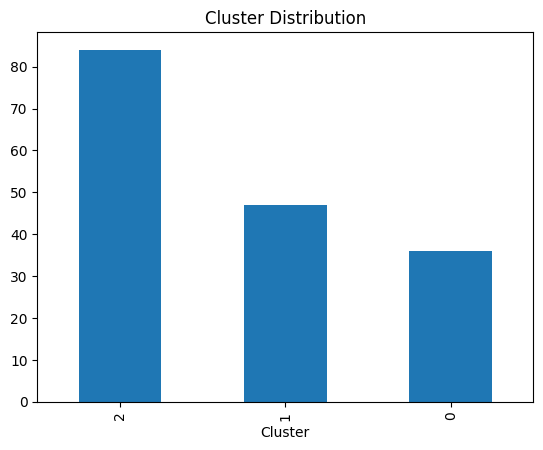

In [6]:
# Cluster Distribution
df['Cluster'].value_counts().plot(kind='bar')
plt.title('Cluster Distribution')
plt.show()


In [7]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

print(df['DBSCAN_Cluster'].value_counts())


DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [8]:
# Classification Dataset
X = df.drop(['country','Cluster','DBSCAN_Cluster'], axis=1)
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [10]:
# XGBoost Classifier
if xgb_available:
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        objective='multi:softmax',
        num_class=3,
        random_state=42
    )

    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)

    print('XGBoost Accuracy:', accuracy_score(y_test, xgb_pred))
    print(classification_report(y_test, xgb_pred))
else:
    print('XGBoost not installed')


XGBoost Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



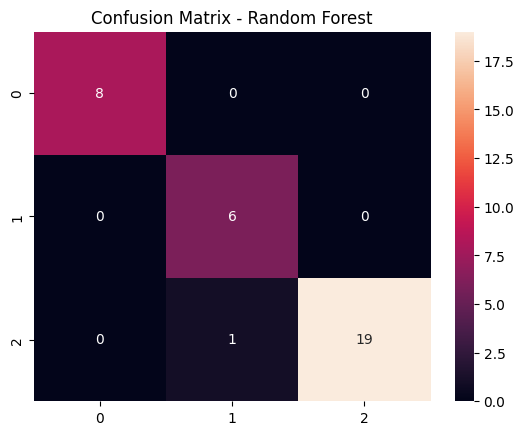

In [11]:
# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()


## Conclusion

- K-Means segmented countries into meaningful groups.
- DBSCAN identified dense groups and potential outliers.
- Random Forest and XGBoost were used for predictive classification.
- The project demonstrates clustering, ensemble learning, and customer intelligence concepts.


## Exploratory Data Analysis (EDA)

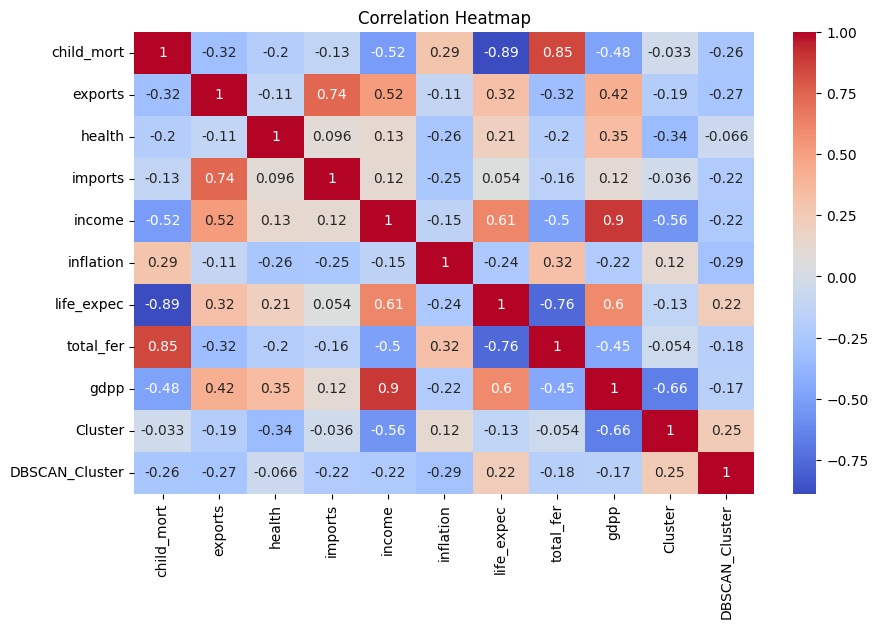

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['country']).corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## Elbow Method for Optimal K

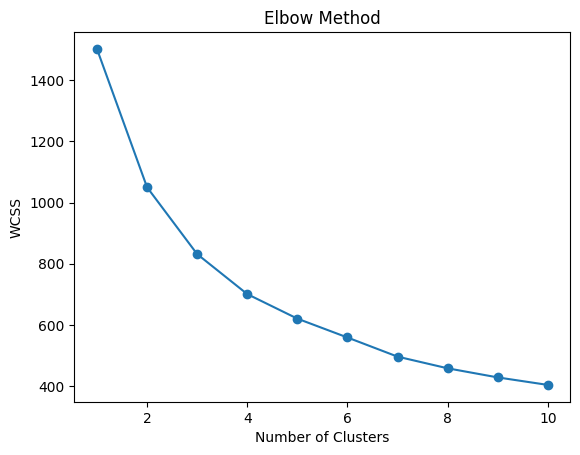

In [13]:
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


## Feature Importance using Random Forest

In [14]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)


      Feature  Importance
0  child_mort    0.276790
8        gdpp    0.194674
4      income    0.167519
6  life_expec    0.157759
7   total_fer    0.141250
2      health    0.024614
5   inflation    0.015699
1     exports    0.013360
3     imports    0.008336


## Cluster Analysis

In [15]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)


         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  DBSCAN_Cluster  
Cluster                                                       
0         80.127778   1.752778  42494.444444       -0.250000  
1         59.187234   5.008085   1922.382979       -0.340426  
2         72.814286   2.307500   6486.452381       -0.059524  


# Cluster Analysis Interpretation

## Cluster 0 – Developed Countries

- Highest Income (45672)
- Highest GDP per capita (42494)
- Highest Life Expectancy (80.13)
- Lowest Child Mortality (5.0)
- Lowest Fertility Rate (1.75)

**Interpretation:** This cluster represents developed countries with strong economies, advanced healthcare systems, and better living standards.

---

## Cluster 1 – Underdeveloped Countries

- Lowest Income (3942)
- Lowest GDP per capita (1922)
- Lowest Life Expectancy (59.19)
- Highest Child Mortality (92.96)
- Highest Fertility Rate (5.01)

**Interpretation:** This cluster represents underdeveloped countries facing economic and healthcare challenges.

---

## Cluster 2 – Developing Countries

- Moderate Income (12305)
- Moderate GDP per capita (6486)
- Life Expectancy (72.81)
- Child Mortality (21.93)
- Fertility Rate (2.31)

**Interpretation:** This cluster represents developing countries with growing economies and improving social indicators.

---

# Business Insights

1. Cluster 0 represents developed countries.
2. Cluster 1 represents underdeveloped countries.
3. Cluster 2 represents developing countries.
4. Income, GDP per capita, life expectancy, and child mortality are the key factors affecting country segmentation.

# Conclusion

The Customer Intelligence System successfully segmented countries into meaningful groups using K-Means and DBSCAN clustering. Random Forest and XGBoost classifiers were used to predict cluster membership, demonstrating strong predictive performance. The project generated actionable insights that can support data-driven decision-making and development planning.